# 04 - Concept Evaluation & Semantic Alignment

In this notebook, we evaluate the **medical concepts extracted by the Sparse Autoencoder (SAE)** by comparing them with the corresponding **Open-I radiology reports**. We use **MedGemma** as a frozen external evaluator to assign an Aligned, Unaligned, or Uncertain verdict to each concept, then inspect the resulting scores and representative clinical cases.

We build on the visual embeddings from Step 01, the phrase-level semantic dictionary from Step 02, and the trained SAE from Step 03.

## 1. Setup and Imports

On Colab, clone the GitHub repository into `/content/xai-project5` to access the project scripts, requirements, and saved artifacts from Steps 01–03. An existing clone is reused when this cell is rerun. Evaluation outputs are saved to Google Drive so they survive runtime resets. Locally, use the existing repository.

Install the required libraries and authenticate with Hugging Face using `HF_TOKEN` from the environment, an existing Hugging Face login, or Colab Secrets. Colab Secrets requires the browser-based Colab UI; when unavailable (for example, from an IDE), Hugging Face may show a warning and fall back to other credentials. If no token is available, enter it in the hidden input prompt. The account must have access to the selected MedGemma model.

The clone contains the files pushed to GitHub; push local code, requirements, or artifact updates before starting a new Colab runtime.

In [1]:
import sys
import os
import subprocess

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    repo_url = "https://github.com/emmanuelmessina00/xai-project5.git"
    base_dir = "/content/xai-project5"

    if not os.path.exists(base_dir):
        subprocess.run(["git", "clone", "--depth", "1", repo_url, base_dir], check=True)
    else:
        print(f"Using existing repository: {base_dir}")

    from google.colab import drive
    drive.mount("/content/drive")
    save_dir = "/content/drive/MyDrive/xai-project5/src/results/04_evaluation"
else:
    base_dir = os.getcwd() if os.path.isdir('src/scripts') else os.path.abspath(os.path.join('..', '..'))
    save_dir = os.path.join(base_dir, 'src', 'results', '04_evaluation')

def resolve_dir(dir_name):
    candidates = [
        f"/content/drive/MyDrive/xai-project5/src/results/{dir_name}",
        f"/content/drive/MyDrive/xai-project5/results/{dir_name}",
        os.path.join(base_dir, 'src', 'results', dir_name),
        os.path.abspath(os.path.join('..', 'results', dir_name))
    ]
    for d in candidates:
        if os.path.isdir(d):
            return d
    return os.path.join(base_dir, 'src', 'results', dir_name)

feat_dir = resolve_dir('01_feature_extraction')
dict_dir = resolve_dir('02_dictionary_creation')
sae_dir = resolve_dir('03_sae_training')
scripts_path = os.path.join(base_dir, 'src', 'scripts')
req_path = os.path.join(base_dir, 'requirements.txt')

candidate_scripts_paths = [
    scripts_path,
    '/content/xai-project5/src/scripts',
    '/content/drive/MyDrive/xai-project5/src/scripts',
    os.path.abspath(os.path.join('..', 'scripts')),
    os.path.abspath(os.path.join('.', 'src', 'scripts'))
]

for path in candidate_scripts_paths:
    if os.path.isdir(path) and path not in sys.path:
        sys.path.insert(0, path)

os.makedirs(save_dir, exist_ok=True)
print(f"Setup complete.\nRepository: {base_dir}\nOutput directory: {save_dir}")


Mounted at /content/drive
Setup complete.
Repository: /content/xai-project5
Output directory: /content/drive/MyDrive/xai-project5/src/results/04_evaluation


In [2]:
!pip install -q -r "{req_path}"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm
from IPython.display import display
from huggingface_hub import login
from transformers import AutoProcessor, AutoModelForImageTextToText

from sae import SparseAutoencoder

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
from getpass import getpass
from huggingface_hub import get_token, login

# Hugging Face handles unavailable Colab Secrets and checks saved credentials.
HF_TOKEN = os.getenv("HF_TOKEN") or get_token()

if not HF_TOKEN:
    # Hidden input also works when connected to a Colab runtime from an IDE.
    HF_TOKEN = getpass("Hugging Face token (input hidden): ").strip()

if not HF_TOKEN:
    raise ValueError("A Hugging Face token with access to MedGemma is required.")

login(token=HF_TOKEN, add_to_git_credential=False)
print("Hugging Face authentication complete.")

Hugging Face token (input hidden): ··········
Hugging Face authentication complete.


## 2. Data Loading

We load the **Open-I visual embeddings and reports** extracted in Step 01. Each embedding must remain paired with its original report, since the report provides the textual evidence used during evaluation.

The semantic dictionary consists of the **phrase-level concept matrix** and its metadata from Step 02. Each row represents a UMLS synonym or an LLM-generated radiology phrase, associated with a parent medical concept.

In [8]:
dataset_filename = 'biomedclip_openi_embeddings_with_reports.pt'

candidate_dataset_paths = [
    os.path.join(feat_dir, dataset_filename),
    f"/content/drive/MyDrive/xai-project5/src/results/01_feature_extraction/{dataset_filename}",
    f"/content/drive/MyDrive/xai-project5/results/01_feature_extraction/{dataset_filename}",
    f"/content/xai-project5/src/results/01_feature_extraction/{dataset_filename}"
]

dataset_path = None
for p in candidate_dataset_paths:
    if os.path.isfile(p):
        dataset_path = p
        break

if dataset_path is None:
    dataset_path = os.path.join(feat_dir, dataset_filename)

print(f"Loading Open-I embeddings and reports from: {dataset_path}")
dataset_data = torch.load(dataset_path, map_location=device)

vision_embeddings = dataset_data['embeddings'].to(torch.float32)
reports = dataset_data['reports']

if len(vision_embeddings) != len(reports):
    raise ValueError("Each visual embedding must have a corresponding report.")

print(f"Visual embeddings shape: {vision_embeddings.shape}")
print(f"Number of reports: {len(reports)}")

Loading Open-I embeddings and reports from: /content/xai-project5/src/results/01_feature_extraction/biomedclip_openi_embeddings_with_reports.pt
Visual embeddings shape: torch.Size([3666, 512])
Number of reports: 3666


In [9]:
matrix_filename = 'biomedclip_phrase_level_concept_matrix.pt'
metadata_filename = 'biomedclip_phrase_level_metadata.csv'

candidate_matrix_paths = [
    os.path.join(dict_dir, matrix_filename),
    f"/content/drive/MyDrive/xai-project5/src/results/02_dictionary_creation/{matrix_filename}",
    f"/content/drive/MyDrive/xai-project5/results/02_dictionary_creation/{matrix_filename}",
    f"/content/xai-project5/src/results/02_dictionary_creation/{matrix_filename}"
]

candidate_meta_paths = [
    os.path.join(dict_dir, metadata_filename),
    f"/content/drive/MyDrive/xai-project5/src/results/02_dictionary_creation/{metadata_filename}",
    f"/content/drive/MyDrive/xai-project5/results/02_dictionary_creation/{metadata_filename}",
    f"/content/xai-project5/src/results/02_dictionary_creation/{metadata_filename}"
]

matrix_path = next((p for p in candidate_matrix_paths if os.path.isfile(p)), os.path.join(dict_dir, matrix_filename))
metadata_path = next((p for p in candidate_meta_paths if os.path.isfile(p)), os.path.join(dict_dir, metadata_filename))

print(f"Loading phrase-level concept matrix from: {matrix_path}")
T_phrases = torch.load(matrix_path, map_location=device)
phrase_metadata = pd.read_csv(metadata_path)

if len(T_phrases) != len(phrase_metadata):
    raise ValueError("Each phrase embedding must have a corresponding metadata row.")

print(f"Phrase-level matrix shape: {T_phrases.shape}")
print(f"Number of parent concepts: {phrase_metadata['parent_concept'].nunique()}")

Loading phrase-level concept matrix from: /content/xai-project5/src/results/02_dictionary_creation/biomedclip_phrase_level_concept_matrix.pt
Phrase-level matrix shape: torch.Size([998, 512])
Number of parent concepts: 100


## 3. Sparse Autoencoder Loading & Semantic Grounding

We load the same **best SAE checkpoint** selected for semantic grounding in Step 03. The SAE remains fixed throughout evaluation.

This copy uses the current phrase-level dictionary and checkpoint from Steps 02-03. The original evaluation notebook used an older concept dictionary and SAE checkpoint, so its saved numerical results should not be treated as results for this configuration.

In [10]:
import glob

INPUT_DIM = vision_embeddings.shape[1]
HIDDEN_DIM = 1024
selected_model = 'sae_model_best_e1000_l5e-05_h1024.pt'

sae = SparseAutoencoder(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM).to(device)

search_dirs = [
    sae_dir,
    "/content/drive/MyDrive/xai-project5/src/results/03_sae_training",
    "/content/drive/MyDrive/xai-project5/results/03_sae_training",
    "/content/xai-project5/src/results/03_sae_training"
]

sae_path = None
for sdir in search_dirs:
    exact = os.path.join(sdir, selected_model)
    if os.path.isfile(exact):
        sae_path = exact
        break
    best_matches = glob.glob(os.path.join(sdir, "sae_model_best_*.pt"))
    if best_matches:
        sae_path = sorted(best_matches, key=os.path.getmtime, reverse=True)[0]
        break

if sae_path is None:
    sae_path = os.path.join(sae_dir, selected_model)

print(f"Loading SAE weights from: {sae_path}")
state_dict = torch.load(sae_path, map_location=device)

if isinstance(state_dict, dict) and 'state_dict' in state_dict:
    sae.load_state_dict(state_dict['state_dict'])
else:
    sae.load_state_dict(state_dict)

sae.eval()
print("SAE loaded and ready for evaluation.")


Loading SAE weights from: /content/drive/MyDrive/xai-project5/src/results/03_sae_training/sae_model_best_e1000_l5e-05_h1024.pt
SAE loaded and ready for evaluation.


### Phrase-to-Concept Aggregation

Following Step 03, we compute the similarity between each normalized text embedding and each normalized SAE decoder column:

$$S_{\mathrm{phrases}} = T_{\mathrm{phrases}} W_{\mathrm{dec}}.$$

We use the full **998 fine-grained phrase-level concept dictionary** ($S_{\mathrm{phrases}} \in \mathbb{R}^{998 \times 1024}$). For each active neuron, the highest-scoring fine-grained phrase concept becomes its semantic label, providing a near 1-to-1 matching ($998 \approx 1024$) with the SAE hidden neurons.


In [11]:
with torch.no_grad():
    sae_decoder_weights = F.normalize(sae.decoder.weight.data, p=2, dim=0)
    phrase_similarities = torch.matmul(T_phrases, sae_decoder_weights)

# Use full 998 fine-grained phrase-level concept dictionary (near 1-to-1 matching with 1024 SAE neurons)
similarities = phrase_similarities
medical_concepts = phrase_metadata['text'].tolist()

print(f"Phrase-level concept similarities matrix shape: {similarities.shape}")
print(f"Total fine-grained medical phrase concepts: {len(medical_concepts)}")


Phrase-level concept similarities matrix shape: torch.Size([998, 1024])
Total fine-grained medical phrase concepts: 998


## 4. Frozen External Evaluator: MedGemma

We use **MedGemma** (`google/medgemma-1.5-4b-it`) to compare each extracted concept with its paired radiology report. Although we load the model through its multimodal interface, this evaluation uses **text only**: the evaluator receives the report and a proposed concept, without the image or SAE activations.

The evaluator is not trained or updated. We retain the original few-shot prompt and generation settings so that the evaluation protocol remains consistent with the original notebook. A GPU is recommended for this inference step.

In [12]:
model_id = "google/medgemma-1.5-4b-it"

model_eval = AutoModelForImageTextToText.from_pretrained(
    model_id,
    dtype=torch.bfloat16,   # Use the same precision as the original evaluation.
    device_map="auto",
)
processor_eval = AutoProcessor.from_pretrained(model_id)

model_eval.eval()
model_eval.requires_grad_(False)
print("MedGemma loaded and ready as a frozen external evaluator.")

config.json:   0%|          | 0.00/2.55k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 33.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

MedGemma loaded and ready as a frozen external evaluator.


### Zero-Shot Semantic Evaluation via Next-Token Logits

This implementation replaces the generative Chain-of-Thought approach with a deterministic, logit-based evaluation strategy, closely mirroring the quantitative methodology of the MedConcept framework.

**The Architectural Shift:**
Allowing the LLM to generate raw text introduces high latency and unpredictable truncation errors. Furthermore, comparing the probabilities of full target words like "Unaligned" and "Uncertain" is technically flawed: tokenizers often split these words into identical prefix subwords (e.g., "Un-"), causing token collisions that invalidate the logit comparison.

**The Solution:**
We reframe the classification task as a strict multiple-choice prompt, mapping the expected verdicts to distinct, single-token identifiers (`A`, `B`, and `C`).

1.  **Forward Pass:** We pass the prompt through the model without triggering the auto-regressive generation loop (`model.generate()`).
2.  **Logit Extraction:** We extract the raw, unnormalized prediction values (logits) for the very last token in the sequence.
3.  **Activation Measurement:** We isolate the specific logits corresponding to the tokens `A`, `B`, and `C`.
4.  **Deterministic Output:** The token with the highest logit value dictates the final verdict.

*Example:* Instead of waiting for the model to articulate a full sentence, we attach a probe to the output layer and measure the activation energy of three specific "neurons" at the exact moment before the model speaks. This reduces inference time from minutes to milliseconds per concept.

In [53]:
import re
import torch
from tqdm import tqdm

def clean_report(text):
    """
    Cleans the radiology report by removing dates, 'XXXX' placeholders,
    and extra whitespaces.
    """
    if not text or not isinstance(text, str):
        return ""
    cleaned = re.sub(r'(?:XXXX|\d{4}-\d{2}-\d{2})\b\s*', '', text)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned
def evaluate_concept_with_llm(report, concept, model, processor, device):
    """
    Evaluates the concept by directly computing the next-token logits.
    Uses the chat template to ensure the instruction-tuned model
    understands it must answer a question, rather than just autocomplete text.
    """
    cleaned_rep = clean_report(report)

    prompt_text = f"""Classify whether a proposed medical concept is supported by a written radiology report. Use only the report text.

Options:
A - Aligned: the report explicitly affirms the concept or a clear synonym.
B - Unaligned: the report explicitly negates the concept or describes a finding that directly contradicts it.
C - Uncertain: the concept is not addressed, is ambiguous, or is only described as possible, suspected, or not excluded.

Rules:
- Absence of mention is not a negation.
- General statements such as "no acute cardiopulmonary abnormality" do not automatically exclude every specific disease.
- For an anatomical structure, an explicit description of that structure, including a normal appearance, supports the anatomical concept.
- Distinguish an anatomical structure from a disease affecting it.

Examples:
Report: "There is a right pleural effusion."
Concept: "pleural effusion"
Label: A

Report: "No pneumothorax or pleural effusion."
Concept: "pneumothorax"
Label: B

Now classify the following:
Report: "{cleaned_rep}"
Concept: "{concept}"
Answer strictly with a single letter: A, B, or C."""

    # We MUST use the chat template so the model acts as an assistant
    messages = [{"role": "user", "content": [{"type": "text", "text": prompt_text}]}]

    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to(model.device)

    # Encode the target letters.
    # Taking the first token [0] ensuring no special tokens are added.
    token_a_id = processor.tokenizer.encode("A", add_special_tokens=False)[0]
    token_b_id = processor.tokenizer.encode("B", add_special_tokens=False)[0]
    token_c_id = processor.tokenizer.encode("C", add_special_tokens=False)[0]

    with torch.inference_mode():
        outputs = model(**inputs)

    next_token_logits = outputs.logits[0, -1, :]

    # --- DEBUGGING LOGIC ---
    top_k = 3
    top_logits, top_indices = torch.topk(next_token_logits, top_k)

    top_tokens = []
    for idx in top_indices:
        decoded_token = processor.tokenizer.decode([idx.item()])
        top_tokens.append(f"'{decoded_token}'")

    top_predictions_log = list(zip(top_tokens, [round(val.item(), 2) for val in top_logits]))
    # -----------------------

    score_a = next_token_logits[token_a_id].item()
    score_b = next_token_logits[token_b_id].item()
    score_c = next_token_logits[token_c_id].item()

    scores = {"Aligned": score_a, "Unaligned": score_b, "Uncertain": score_c}
    best_verdict = max(scores, key=scores.get)

    print(f"\n[LOG] Concept: {concept!r}")
    print(f"      Target Logits -> A: {score_a:.2f} | B: {score_b:.2f} | C: {score_c:.2f}")
    print(f"      Model's actual Top-{top_k} choices: {top_predictions_log}")
    print(f"      => Chosen Verdict: {best_verdict}")

    return best_verdict

## 5. Concept Extraction & Quantitative Evaluation

For each selected Open-I embedding, we obtain the SAE activations and retain up to **TOP_K = 10 neurons** meeting an activation threshold ($z_j > 0.01$). We map these neurons to their closest phrase concepts with cosine similarity $\ge 0.20$ and remove duplicate concept labels before querying MedGemma.

For an image $i$ with a non-empty set of predicted concepts $C_i$, each score is the fraction of concepts assigned the corresponding verdict:

$$\mathrm{Score}_{v}(i) = \frac{1}{|C_i|}\sum_{c \in C_i}\mathbb{1}[\mathrm{verdict}(c, r_i)=v],$$

where $v$ is Aligned, Unaligned, or Uncertain, and $r_i$ is the associated report. The three scores therefore sum to one for each evaluated image.

As in the original notebook, we inspect the **first 10 dataset entries**. Entries without a usable report or positively activated neurons are skipped, so the final number of evaluated images may be smaller than `NUM_SAMPLES`.


In [54]:
TOP_K = 10
NUM_SAMPLES = 10

In [55]:
results = []

print(f"Evaluating up to {NUM_SAMPLES} images using MedGemma...\n")

for i in tqdm(range(min(NUM_SAMPLES, len(vision_embeddings)))):
    img_emb = vision_embeddings[i].unsqueeze(0).to(device)

    try:
        report = reports[i]
    except Exception:
        continue

    cleaned_rep = clean_report(report)

    if not cleaned_rep or len(cleaned_rep) < 5:
        continue

    with torch.no_grad():
        _, z = sae(img_emb)

    activations = z[0]

    top_vals, top_indices = torch.topk(activations, TOP_K)
    # Select positively activated neurons (z_j > 0.0)
    active_neurons = top_indices[top_vals > 0.0]

    if len(active_neurons) == 0:
        continue

    predicted_concepts = set()

    for neuron_idx in active_neurons:
        neuron_concept_scores = similarities[:, neuron_idx]
        best_concept_idx = torch.argmax(neuron_concept_scores).item()
        concept = medical_concepts[best_concept_idx]
        predicted_concepts.add(concept)

    predicted_concepts = sorted(predicted_concepts)

    aligned_count = 0
    unaligned_count = 0
    uncertain_count = 0
    concept_details = []

    for concept in predicted_concepts:
        verdict = evaluate_concept_with_llm(cleaned_rep, concept, model_eval, processor_eval, device)

        if verdict == "Aligned":
            aligned_count += 1
        elif verdict == "Unaligned":
            unaligned_count += 1
        else:
            uncertain_count += 1

        concept_details.append({"concept": concept, "verdict": verdict})

    total = len(predicted_concepts)

    if total > 0:
        results.append({
            "image_index": i,
            "report": cleaned_rep,
            "total_concepts_found": total,
            "aligned_score": aligned_count / total,
            "unaligned_score": unaligned_count / total,
            "uncertain_score": uncertain_count / total,
            "details": concept_details
        })


Evaluating up to 10 images using MedGemma...



  0%|          | 0/10 [00:00<?, ?it/s]


[LOG] Concept: 'atheroscleroses'
      Target Logits -> A: 16.38 | B: 16.38 | C: 20.00
      Model's actual Top-3 choices: [("'C'", 20.0), ("'B'", 16.38), ("'A'", 16.38)]
      => Chosen Verdict: Uncertain

[LOG] Concept: 'atrial structure (body structure)'
      Target Logits -> A: 18.25 | B: 16.75 | C: 19.00
      Model's actual Top-3 choices: [("'C'", 19.0), ("'A'", 18.25), ("'The'", 16.88)]
      => Chosen Verdict: Uncertain

[LOG] Concept: 'cardiac ventricular morphology contributes to the overall size of the cardiac silhouette.'
      Target Logits -> A: 17.75 | B: 16.25 | C: 19.62
      Model's actual Top-3 choices: [("'C'", 19.62), ("'A'", 17.75), ("'The'", 16.5)]
      => Chosen Verdict: Uncertain

[LOG] Concept: 'cardiomegaly with prominent pulmonary vascular congestion and bilateral perihilar interstitial opacities.'
      Target Logits -> A: 17.75 | B: 17.25 | C: 20.12
      Model's actual Top-3 choices: [("'C'", 20.12), ("'A'", 17.75), ("'B'", 17.25)]
      => Chosen Verd

 10%|█         | 1/10 [00:11<01:40, 11.21s/it]


[LOG] Concept: 'solitary circumscribed mass lesion projecting over the right mid lung zone.'
      Target Logits -> A: 16.75 | B: 17.25 | C: 20.25
      Model's actual Top-3 choices: [("'C'", 20.25), ("'B'", 17.25), ("'A'", 16.75)]
      => Chosen Verdict: Uncertain

[LOG] Concept: 'cardiac ventricular morphology contributes to the overall size of the cardiac silhouette.'
      Target Logits -> A: 20.25 | B: 17.50 | C: 19.00
      Model's actual Top-3 choices: [("'A'", 20.25), ("'C'", 19.0), ("'The'", 17.62)]
      => Chosen Verdict: Aligned

[LOG] Concept: 'column, vertebral'
      Target Logits -> A: 16.62 | B: 18.00 | C: 19.62
      Model's actual Top-3 choices: [("'C'", 19.62), ("'B'", 18.0), ("'A'", 16.62)]
      => Chosen Verdict: Uncertain

[LOG] Concept: 'layering opacity along the lateral chest wall indicates pleural effusion.'
      Target Logits -> A: 18.38 | B: 18.50 | C: 19.38
      Model's actual Top-3 choices: [("'C'", 19.38), ("'B'", 18.5), ("'A'", 18.38)]
      => Cho

...


[LOG] Concept: 'visualized thoracic skeletal deformity with abnormal configuration of the bony thorax.'
      Target Logits -> A: 19.12 | B: 17.50 | C: 20.12
      Model's actual Top-3 choices: [("'C'", 20.12), ("'A'", 19.12), ("'B'", 17.5)]
      => Chosen Verdict: Uncertain

[LOG] Concept: 'a solitary well-defined nodule with central dense calcification is noted.'
      Target Logits -> A: 16.00 | B: 18.25 | C: 20.88
      Model's actual Top-3 choices: [("'C'", 20.88), ("'B'", 18.25), ("'The'", 16.38)]
      => Chosen Verdict: Uncertain

[LOG] Concept: 'a solitary well-defined rounded opacity is noted within the right upper lobe.'
      Target Logits -> A: 15.94 | B: 18.25 | C: 20.12
      Model's actual Top-3 choices: [("'C'", 20.12), ("'B'", 18.25), ("'The'", 16.12)]
      => Chosen Verdict: Uncertain

[LOG] Concept: 'abnormal separation of the articular surfaces within the acromioclavicular joint.'
      Target Logits -> A: 16.12 | B: 18.50 | C: 20.62
      Model's actual Top-3 c

 90%|█████████ | 9/10 [01:57<00:13, 13.94s/it]


[LOG] Concept: 'thoracic aorta appears as a well defined tubular structure within the superior mediastinum.'
      Target Logits -> A: 17.88 | B: 18.62 | C: 20.00
      Model's actual Top-3 choices: [("'C'", 20.0), ("'B'", 18.62), ("'A'", 17.88)]
      => Chosen Verdict: Uncertain

[LOG] Concept: 'abnormal separation of the articular surfaces within the acromioclavicular joint.'
      Target Logits -> A: 16.50 | B: 17.38 | C: 20.88
      Model's actual Top-3 choices: [("'C'", 20.88), ("'B'", 17.38), ("'A'", 16.5)]
      => Chosen Verdict: Uncertain

[LOG] Concept: 'cardiomegaly with prominent pulmonary vascular congestion and bilateral perihilar interstitial opacities.'
      Target Logits -> A: 16.75 | B: 17.88 | C: 20.88
      Model's actual Top-3 choices: [("'C'", 20.88), ("'B'", 17.88), ("'A'", 16.75)]
      => Chosen Verdict: Uncertain

[LOG] Concept: 'fibrocystic disease'
      Target Logits -> A: 16.00 | B: 15.75 | C: 20.75
      Model's actual Top-3 choices: [("'C'", 20.75), (

100%|██████████| 10/10 [02:11<00:00, 13.11s/it]


[LOG] Concept: 'the thoracic aorta maintains a smooth lateral contour along the upper mediastinal stripe.'
      Target Logits -> A: 19.38 | B: 17.12 | C: 18.38
      Model's actual Top-3 choices: [("'A'", 19.38), ("'C'", 18.38), ("'The'", 17.5)]
      => Chosen Verdict: Aligned


### Evaluation Results

We display the per-image results and the mean Aligned, Unaligned, and Uncertain scores across evaluated images. These means give each image equal weight, regardless of the number of distinct extracted concepts.

In [56]:
result_columns = [
    'image_index', 'report', 'total_concepts_found',
    'aligned_score', 'unaligned_score', 'uncertain_score', 'details'
]
df_evaluation = pd.DataFrame(results, columns=result_columns)

print(f"Evaluation complete. Evaluated {len(df_evaluation)} valid images.")
display(df_evaluation.head())

if not df_evaluation.empty:
    score_columns = ['aligned_score', 'unaligned_score', 'uncertain_score']
    display(df_evaluation[score_columns].mean().to_frame(name='Mean score'))
else:
    print("No valid images were evaluated. Check the reports and SAE activations.")

Evaluation complete. Evaluated 10 valid images.


,image_index,report,total_concepts_found,aligned_score,unaligned_score,uncertain_score,details
0,0,The cardiac silhouette and mediastinum size ar...,9,0.000000,0.0,1.000000,"[{'concept': 'atheroscleroses', 'verdict': 'Un..."
1,1,Borderline cardiomegaly. Midline sternotomy . ...,9,0.111111,0.0,0.888889,[{'concept': 'cardiac ventricular morphology c...
2,2,"No displaced rib fractures, pneumothorax, or p...",10,0.300000,0.0,0.700000,[{'concept': 'discrete radiopaque biliary calc...
3,3,There are diffuse bilateral interstitial and a...,10,0.000000,0.0,1.000000,[{'concept': 'abnormal separation of the artic...
4,4,The cardiomediastinal silhouette and pulmonary...,9,0.111111,0.0,0.888889,[{'concept': 'confluent airspace opacification...


,Mean score
aligned_score,0.112222
unaligned_score,0.000000
uncertain_score,0.887778


## 6. Qualitative Analysis: Best, Median & Worst Cases

We rank the evaluated images by their **Aligned score** and inspect the first, middle, and last rows. For each case, we display the original report, the three scores, and the concept-level verdicts.

These cases help us examine agreement, ambiguity, and possible mismatches. The ranking is based only on the Aligned score: a low score can reflect uncertainty as well as contradiction. Tied scores do not establish a meaningful difference in explanation quality, and with fewer than three evaluated images, a case can appear more than once.

In [57]:
valid_df = df_evaluation[df_evaluation['total_concepts_found'] > 0].copy()
sorted_df = valid_df.sort_values(by='aligned_score', ascending=False).reset_index(drop=True)

if sorted_df.empty:
    print("No evaluated cases are available for qualitative analysis.")
else:
    case_studies = {
        "BEST CASE (Highest Aligned Score)": sorted_df.iloc[0],
        "MEDIAN CASE (Middle-Ranked Image)": sorted_df.iloc[len(sorted_df) // 2],
        "WORST CASE (Lowest Aligned Score)": sorted_df.iloc[-1]
    }

    for title, case in case_studies.items():
        print("-" * 60)
        print(title)
        print(f"Original image index: {case['image_index']}")
        print(
            f"Scores -> Aligned: {case['aligned_score']:.2f} | "
            f"Unaligned: {case['unaligned_score']:.2f} | "
            f"Uncertain: {case['uncertain_score']:.2f}"
        )
        print(f"\nORIGINAL RADIOLOGY REPORT:\n{case['report']}\n")
        print("SAE CONCEPTS AND MEDGEMMA VERDICTS:")
        for detail in case['details']:
            print(f"  {detail['concept']:<25} -> {detail['verdict']}")
        print()

------------------------------------------------------------
BEST CASE (Highest Aligned Score)
Original image index: 2
Scores -> Aligned: 0.30 | Unaligned: 0.00 | Uncertain: 0.70

ORIGINAL RADIOLOGY REPORT:
No displaced rib fractures, pneumothorax, or pleural effusion identified. Well-expanded and clear lungs. Mediastinal contour within normal limits. No acute cardiopulmonary abnormality identified.

SAE CONCEPTS AND MEDGEMMA VERDICTS:
  discrete radiopaque biliary calculus projected over the right hepatic shadow. -> Uncertain
  focal pulmonary opacity with smooth margins located in the left upper lobe. -> Uncertain
  gallstone diseases        -> Uncertain
  generalized thinning of the cortical margins of the visualized ribs. -> Uncertain
  multiple ring shadows and tubular opacities consistent with widespread cystic bronchiectasis. -> Uncertain
  regional hyperlucency of the upper lung zone with decreased density of pulmonary vasculature. -> Uncertain
  the cervical spine demonstrates

### Interpretation of the Scores

These scores measure **agreement with the written report under the chosen evaluation protocol**. They do not directly establish whether a concept is visible in the image or whether the SAE representation is clinically correct. Reports may omit findings, and the evaluator's prompt and generated responses can affect the verdicts.

The 10-entry subset provides an initial inspection of the pipeline. Broader evaluation and manual review of ambiguous or inconsistent cases are needed before drawing general conclusions about concept quality.

-------------------

📊 DETAILED QUANTITATIVE ANALYSIS OF EVALUATION RESULTS
Images Evaluated:             10
Average Concepts per Image:   9.7
Average Aligned Score:        11.22%
Average Unaligned Score:      0.00%
Average Uncertain Score:      88.78%


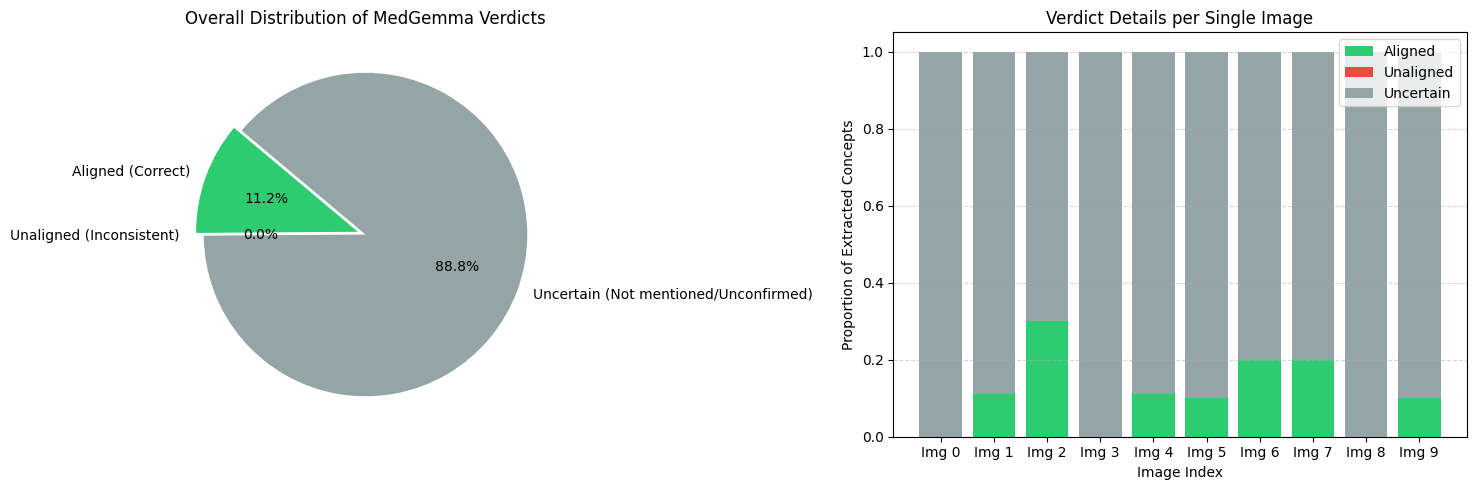

In [58]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Convert results into a Pandas DataFrame
df_eval = pd.DataFrame(results)

print("=" * 65)
print("📊 DETAILED QUANTITATIVE ANALYSIS OF EVALUATION RESULTS")
print("=" * 65)
print(f"Images Evaluated:             {len(df_eval)}")
print(f"Average Concepts per Image:   {df_eval['total_concepts_found'].mean():.1f}")
print(f"Average Aligned Score:        {df_eval['aligned_score'].mean()*100:.2f}%")
print(f"Average Unaligned Score:      {df_eval['unaligned_score'].mean()*100:.2f}%")
print(f"Average Uncertain Score:      {df_eval['uncertain_score'].mean()*100:.2f}%")
print("=" * 65)

# Create Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Pie Chart of Verdict Distribution
mean_scores = [df_eval['aligned_score'].mean(), df_eval['unaligned_score'].mean(), df_eval['uncertain_score'].mean()]
labels = ['Aligned (Correct)', 'Unaligned (Inconsistent)', 'Uncertain (Not mentioned/Unconfirmed)']
colors = ['#2ecc71', '#e74c3c', '#95a5a6']
explode = (0.05, 0.05, 0)

axes[0].pie(mean_scores, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140, explode=explode)
axes[0].set_title('Overall Distribution of MedGemma Verdicts')

# Plot 2: Stacked Bar Chart per Single Image
indices = [f"Img {idx}" for idx in df_eval['image_index']]
axes[1].bar(indices, df_eval['aligned_score'], label='Aligned', color='#2ecc71')
axes[1].bar(indices, df_eval['unaligned_score'], bottom=df_eval['aligned_score'], label='Unaligned', color='#e74c3c')
axes[1].bar(indices, df_eval['uncertain_score'], bottom=df_eval['aligned_score']+df_eval['unaligned_score'], label='Uncertain', color='#95a5a6')

axes[1].set_xlabel('Image Index')
axes[1].set_ylabel('Proportion of Extracted Concepts')
axes[1].set_title('Verdict Details per Single Image')
axes[1].legend(loc='upper right')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()